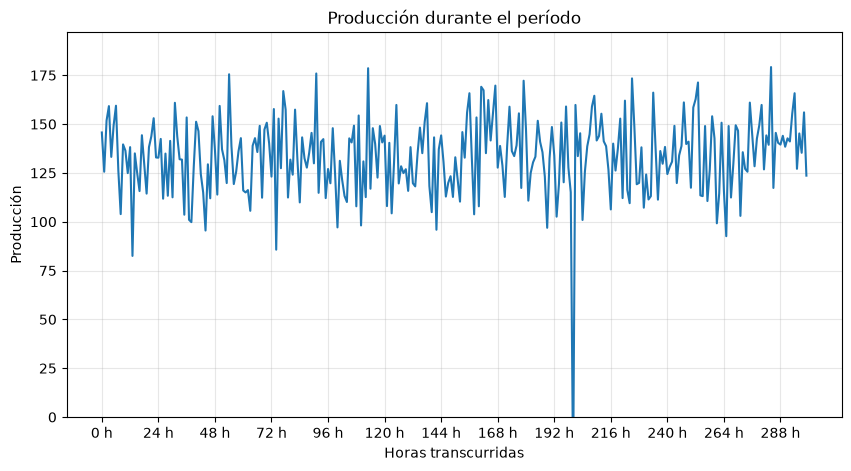

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./sensores.csv")

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df.index, df["produccion"])

ax.set_title("Producción durante el período")
ax.set_xlabel("Horas transcurridas")
ax.set_ylabel("Producción")

ax.set_ylim(0, df["produccion"].max() * 1.1)

ax.set_xticks(range(0, 301, 24))
ax.set_xticklabels([f"{h} h" for h in range(0, 301, 24)])

ax.grid(True, alpha=0.3)

plt.show()

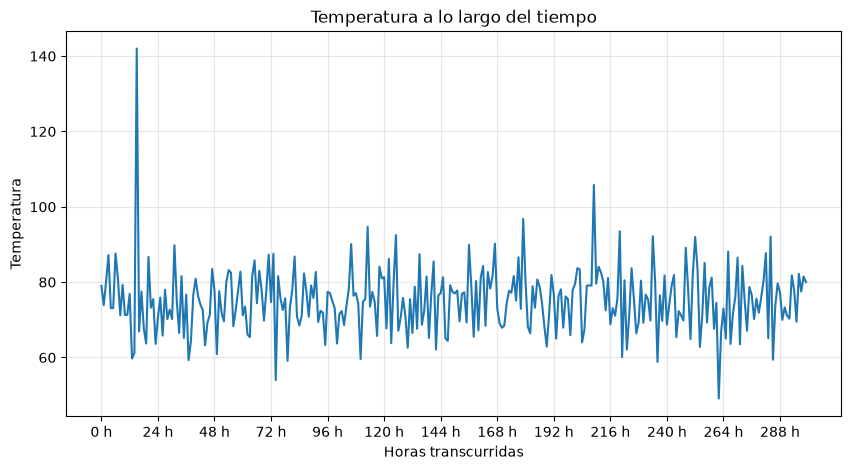

In [14]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df.index, df["temperatura"])

ax.set_title("Temperatura a lo largo del tiempo")
ax.set_xlabel("Horas transcurridas")
ax.set_ylabel("Temperatura")

ax.set_xticks(range(0, 301, 24))
ax.set_xticklabels([f"{h} h" for h in range(0, 301, 24)])

ax.grid(True, alpha=0.3)

plt.show()

turno
Tarde     161.304167
Mañana    160.332000
Noche     157.897115
Name: consumo_kwh, dtype: float64


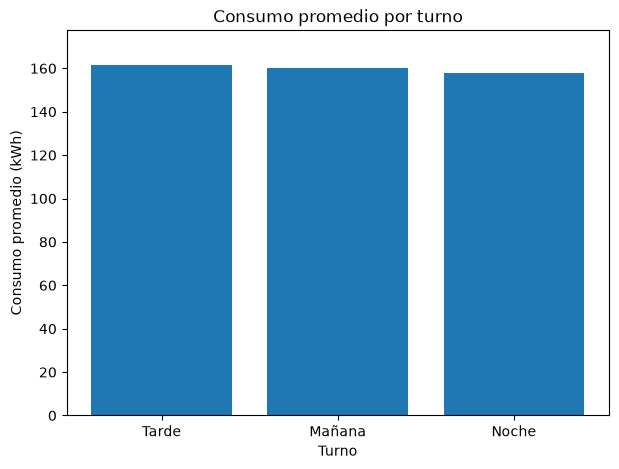

In [15]:
# Crear la hora del día a partir del índice
hora = df.index % 24

# Crear los turnos
df["turno"] = pd.cut(
    hora,
    bins=[-1, 7, 15, 23],
    labels=["Noche", "Mañana", "Tarde"]
)

# Calcular consumo promedio por turno y ordenar de mayor a menor
consumo_turno = (
    df.groupby("turno", observed=True)["consumo_kwh"]
    .mean()
    .sort_values(ascending=False)
)

print(consumo_turno)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(consumo_turno.index, consumo_turno.values)

ax.set_title("Consumo promedio por turno")
ax.set_xlabel("Turno")
ax.set_ylabel("Consumo promedio (kWh)")

# Las barras empiezan en 0
ax.set_ylim(0, consumo_turno.max() * 1.1)

plt.show()

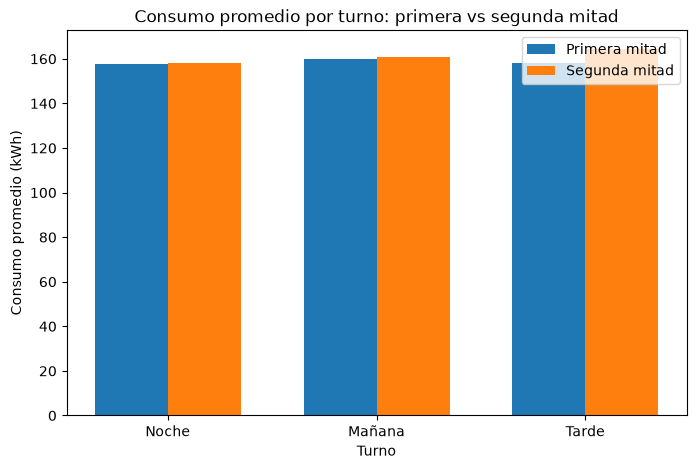

In [20]:
# Dividir el dataset en dos mitades
primera_mitad = df.iloc[:150]
segunda_mitad = df.iloc[150:]

# Calcular el consumo promedio por turno
promedio_primera = primera_mitad.groupby("turno")["consumo_kwh"].mean()
promedio_segunda = segunda_mitad.groupby("turno")["consumo_kwh"].mean()

# Posiciones de los turnos
x = np.arange(len(promedio_primera))
ancho = 0.35

# Crear gráfico de barras agrupadas
plt.figure(figsize=(8, 5))

plt.bar(x - ancho/2, promedio_primera, ancho, label="Primera mitad")
plt.bar(x + ancho/2, promedio_segunda, ancho, label="Segunda mitad")

plt.xlabel("Turno")
plt.ylabel("Consumo promedio (kWh)")
plt.title("Consumo promedio por turno: primera vs segunda mitad")
plt.xticks(x, promedio_primera.index)
plt.legend()

plt.show()

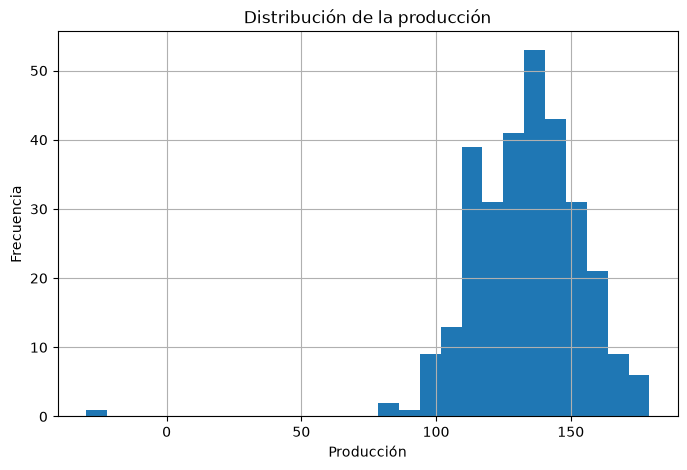

In [22]:
plt.figure(figsize=(8, 5))

df["produccion"].hist(bins="fd")

plt.xlabel("Producción")
plt.ylabel("Frecuencia")
plt.title("Distribución de la producción")

# Observación: la distribución presenta una forma aproximadamente simétrica,
# similar a una campana, sin valores extremos o comportamientos inusuales visibles.

plt.show()

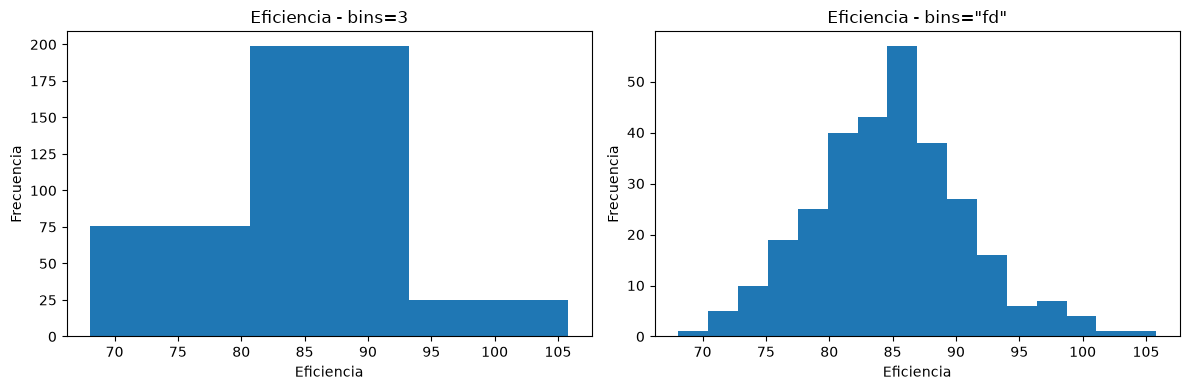

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con bins=3
axes[0].hist(df["eficiencia"], bins=3)
axes[0].set_title("Eficiencia - bins=3")
axes[0].set_xlabel("Eficiencia")
axes[0].set_ylabel("Frecuencia")

# Histograma con bins="fd"
axes[1].hist(df["eficiencia"], bins="fd")
axes[1].set_title('Eficiencia - bins="fd"')
axes[1].set_xlabel("Eficiencia")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

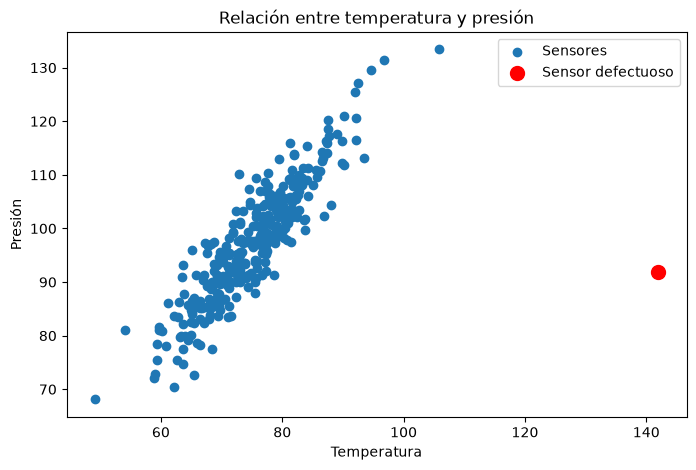

In [26]:
indice_defectuoso = 15

plt.figure(figsize=(8, 5))

plt.scatter(df["temperatura"], df["presion"], label="Sensores")

plt.scatter(
    df.loc[indice_defectuoso, "temperatura"],
    df.loc[indice_defectuoso, "presion"],
    color="red",
    s=100,
    label="Sensor defectuoso"
)

plt.xlabel("Temperatura")
plt.ylabel("Presión")
plt.title("Relación entre temperatura y presión")
plt.legend()
plt.show()

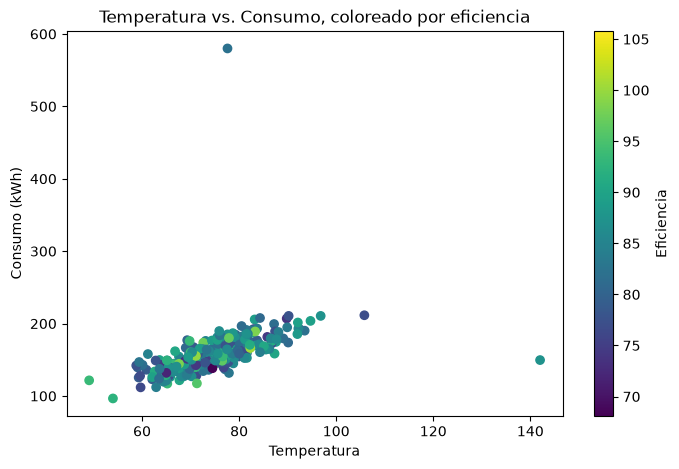

In [27]:

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    df["temperatura"],
    df["consumo_kwh"],
    c=df["eficiencia"],
    cmap="viridis"
)

ax.set_xlabel("Temperatura")
ax.set_ylabel("Consumo (kWh)")
ax.set_title("Temperatura vs. Consumo, coloreado por eficiencia")

fig.colorbar(scatter, ax=ax, label="Eficiencia")

plt.show()

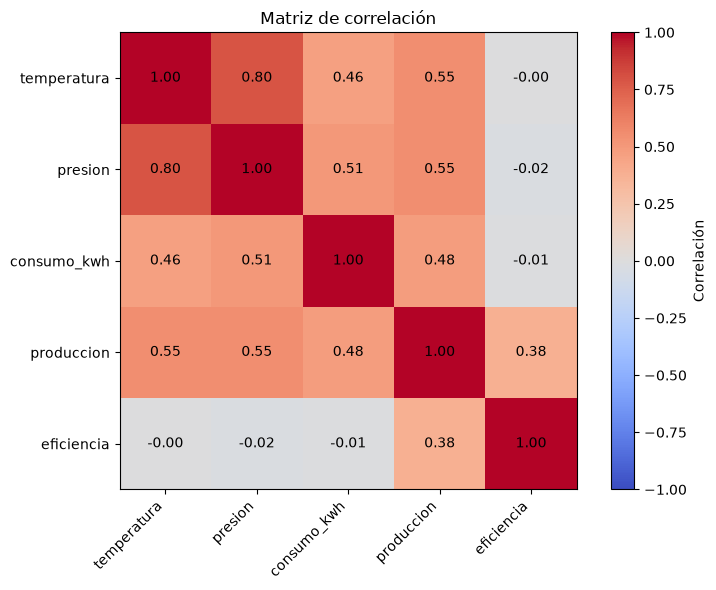

In [28]:
columnas = [
    "temperatura",
    "presion",
    "consumo_kwh",
    "produccion",
    "eficiencia"
]

corr = df[columnas].corr()

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Nombres de las variables
ax.set_xticks(range(len(columnas)))
ax.set_yticks(range(len(columnas)))
ax.set_xticklabels(columnas, rotation=45, ha="right")
ax.set_yticklabels(columnas)

# Escribir los valores dentro de cada celda
for i in range(len(columnas)):
    for j in range(len(columnas)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(im, ax=ax, label="Correlación")

ax.set_title("Matriz de correlación")

plt.tight_layout()
plt.show()

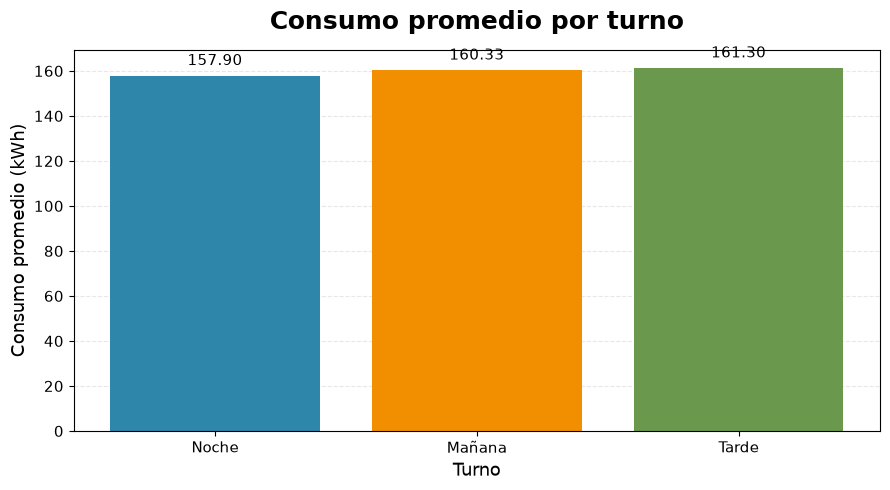

In [29]:
# Calcular consumo promedio por turno
consumo_turno = df.groupby("turno")["consumo_kwh"].mean()

fig, ax = plt.subplots(figsize=(9, 5))

# Paleta consistente
colores = ["#2E86AB", "#F18F01", "#6A994E", "#9B5DE5"]

barras = ax.bar(
    consumo_turno.index,
    consumo_turno.values,
    color=colores[:len(consumo_turno)]
)

# Título y etiquetas
ax.set_title(
    "Consumo promedio por turno",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Turno", fontsize=13)
ax.set_ylabel("Consumo promedio (kWh)", fontsize=13)

# Tamaño legible de los valores
ax.tick_params(axis="both", labelsize=11)

# Valores arriba de cada barra
ax.bar_label(
    barras,
    fmt="%.2f",
    padding=5,
    fontsize=11
)

# Grilla suave
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Evitar que la grilla quede por delante de las barras
ax.set_axisbelow(True)

plt.tight_layout()

# Guardar imagen
plt.savefig(
    "consumo_por_turno.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

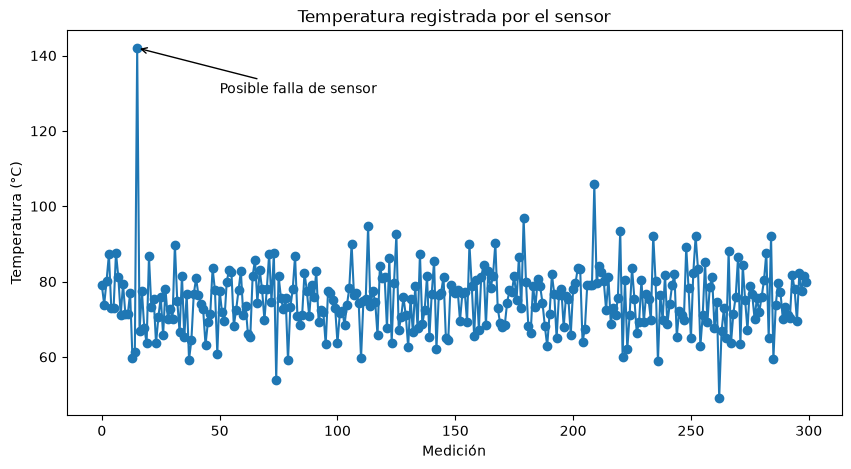

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(df.index, df["temperatura"], marker="o")

plt.title("Temperatura registrada por el sensor")
plt.xlabel("Medición")
plt.ylabel("Temperatura (°C)")

ax = plt.gca()

ax.annotate(
    "Posible falla de sensor",
    xy=(15, df.loc[15, "temperatura"]),
    xytext=(50, 130),
    arrowprops=dict(
        facecolor="black",
        arrowstyle="->"
    )
)

plt.show()